# Steady-state beam diameter $d(\nu)$ — fully random slab 250×250×32 µm, n = 3.3 (physics & verdicts: `README.md`)

In [1]:
# --- constants & paths (experiment facts: README.md) --------------------------
import os, sys, gc
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from scipy.integrate import simpson
from scipy.ndimage import uniform_filter1d
from scipy.special import j0
sys.path.append(os.path.abspath(r'../../../../../tidy3d'))
import AutomationModule as AM
plt.rc('font', family='Arial')

a       = 2.562629142772549   # unit length a [um] (nu = a/lambda)
L_slab  = 32.0                # slab thickness [um] = 12.487 a
G       = "3.30"              # h5 group (n = 3.30)
GAP_DESIGN = (0.388, 0.435)   # 2026-07 campaign design window (reference only;
                              # the gap is located empirically from S(nu) below)
file_data = "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_3p3__lsu_generated_healed_lambda_4_8.h5"
file_ls   = r"../20251002_Ls_test/data/ls_values/20251031_ls_values_n_3p3.h5"
file_nuls = r"../20251029_T(L)/data/20251030_ff_2237_circular_rods_n_3p3_2.h5"  # nu axis of file_ls
file_g    = r"../data/g_values/n_3.3_ff_0.2237_g_data.h5"                       # faithful n=3.3 g(nu)

In [2]:
# --- load exit-face fields (~4.7 GB in RAM); axes; PR estimator + unit test ----
data = AM.read_hdf5_as_dict(file_data)
xg = np.asarray(data[G]["x"], float); yg = np.asarray(data[G]["y"], float)
nu = a*np.asarray(data[G]["f"], float)/td.C_0            # ascending, 1500 bins
nx, ny, N = xg.size, yg.size, nu.size
dnu = float(np.mean(np.diff(nu)))
wxS = simpson(np.eye(nx), x=xg, axis=1)                  # product-Simpson weights
wyS = simpson(np.eye(ny), x=yg, axis=1)                  # (exact non-uniform grid)

def diameter(I, x, y):
    '''PR beam diameter d = 2 sqrt(A_eff/pi), A_eff = (int I dA)^2 / int I^2 dA.
    Scale-invariant; background-robust; biased LOW ~sqrt(1+1/M)~1.15 on one
    speckle realization (M~3 components). Works on (nx,ny) or (nx,ny,nf).'''
    i1 = simpson(simpson(I**2, x=y, axis=1), x=x, axis=0)
    i2 = simpson(simpson(I,    x=y, axis=1), x=x, axis=0)**2
    return 2*np.sqrt((i2/i1)/np.pi)

# unit test: PR diameter of a Gaussian I=exp(-rho^2/2s^2) equals 4s exactly
Xg, Yg = np.meshgrid(xg, yg, indexing="ij"); Rg2 = Xg**2 + Yg**2
for s in (5.0, 12.0, 25.0):
    assert abs(diameter(np.exp(-Rg2/(2*s*s)), xg, yg)/(4*s) - 1) < 1e-4
print(f"grid {nx}x{ny}, nu = [{nu[0]:.4f}, {nu[-1]:.4f}], dnu = {dnu:.3e}; Gaussian unit test OK")

grid 363x363, nu = [0.3203, 0.6407], dnu = 2.137e-04; Gaussian unit test OK


## One streaming pass: $S(\nu)$, $d(\nu)$, $\langle\rho^2\rangle$, $d_{avg}$, sampling/edge diagnostics, core spectra

In [3]:
# --- memory-light block streaming over the in-RAM fields (validated pipeline) --
for _v in ("I", "Icore", "maps_sel"): globals().pop(_v, None)
gc.collect()
Ex_, Ey_, Ez_ = data[G]["Ex"], data[G]["Ey"], data[G]["Ez"]      # (nx,ny,1,N) complex64
WBOX = (11, 45, 181)                                             # d_avg boxcar widths
S1 = np.zeros(N); S2 = np.zeros(N); M2 = np.zeros(N)             # int I, I^2, rho^2 I dA
S1b = {w: np.zeros(N) for w in WBOX}; S2b = {w: np.zeros(N) for w in WBOX}
S1d2 = np.zeros(N); S2d2 = np.zeros(N)                           # 2x-decimated grid
S1a40 = np.zeros(N); S2a40 = np.zeros(N)                         # sub-aperture rho<40a
P_rim = np.zeros(N)                                              # rho>45a rim power
i2d = np.arange(0, nx, 2)
wx2 = simpson(np.eye(i2d.size), x=xg[i2d], axis=1); wy2 = simpson(np.eye(i2d.size), x=yg[i2d], axis=1)
Rg = np.sqrt(Rg2); core_mask = Rg < 15*a; _core = []
wyS_y2 = wyS*yg**2
BL = 33
for i0 in range(0, nx, BL):
    i1 = min(i0+BL, nx)
    I = np.abs(Ex_[i0:i1, :, 0, :])**2
    I += np.abs(Ey_[i0:i1, :, 0, :])**2
    I += np.abs(Ez_[i0:i1, :, 0, :])**2
    I = I.astype(np.float64)*1e30                                # global scale cancels
    wxb = wxS[i0:i1]; aw = wxb[:, None]*wyS[None, :]
    Ay  = np.tensordot(I,    wyS,    axes=([1], [0]))
    A2y = np.tensordot(I**2, wyS,    axes=([1], [0]))
    By  = np.tensordot(I,    wyS_y2, axes=([1], [0]))
    S1 += (wxb[:, None]*Ay).sum(0); S2 += (wxb[:, None]*A2y).sum(0)
    M2 += (wxb[:, None]*((xg[i0:i1]**2)[:, None]*Ay + By)).sum(0)
    rows = np.where(np.isin(np.arange(i0, i1), i2d))[0]          # decimated subgrid
    Id = I[rows][:, i2d]
    S1d2 += (wx2[(np.arange(i0, i1)[rows])//2, None]*np.tensordot(Id,    wy2, axes=([1], [0]))).sum(0)
    S2d2 += (wx2[(np.arange(i0, i1)[rows])//2, None]*np.tensordot(Id**2, wy2, axes=([1], [0]))).sum(0)
    m40 = Rg[i0:i1] <= 40*a
    S1a40 += np.einsum("pn,p->n", I[m40], aw[m40]); S2a40 += np.einsum("pn,p->n", I[m40]**2, aw[m40])
    mrim = Rg[i0:i1] > 45*a
    if mrim.any(): P_rim += np.einsum("pn,p->n", I[mrim], aw[mrim])
    for w in WBOX:
        Ism = uniform_filter1d(I, size=w, axis=-1, mode="nearest")
        S1b[w] += (wxb[:, None]*np.tensordot(Ism,    wyS, axes=([1], [0]))).sum(0)
        S2b[w] += (wxb[:, None]*np.tensordot(Ism**2, wyS, axes=([1], [0]))).sum(0)
        del Ism
    cm = core_mask[i0:i1]
    if cm.any(): _core.append(I[cm].astype(np.float32))
    del I, Id, Ay, A2y, By; gc.collect()
    print(f"rows {i1}/{nx}", end="\r")
Icore = np.vstack(_core); del _core
d_of  = lambda s1, s2: 2*np.sqrt((s1**2/s2)/np.pi)/a
d_nu  = d_of(S1, S2)                       # PRIMARY: raw per-bin PR diameter [a]
sig2  = (M2/S1)/a**2                       # secondary (background-sensitive)
davg  = {w: d_of(S1b[w], S2b[w]) for w in WBOX}
d_dec2, d_ap40, rim_frac = d_of(S1d2, S2d2), d_of(S1a40, S2a40), P_rim/S1
print(f"\nd(0.50) = {d_nu[np.argmin(np.abs(nu-0.50))]:.2f} a   "
      f"mid-band median d[0.50-0.62] = {np.median(d_nu[(nu>=0.50)&(nu<=0.62)]):.2f} a")

rows 363/363
d(0.50) = 27.31 a   mid-band median d[0.50-0.62] = 27.56 a


In [4]:
# --- speckle statistics -> error model; sampling & d_avg convergence checks ----
band = (nu >= 0.50) & (nu <= 0.62)                         # smooth diffusive band
Ic = Icore[:, band].astype(np.float64)
Ic /= uniform_filter1d(Ic, 41, axis=1, mode="nearest")     # detrend slow envelope
C_sp = float(np.nanmean(Ic.std(1)))                        # spectral-detrend contrast
# window-free SPATIAL contrast (cross-check: the spectral value depends on the
# detrend window; adversarial verify 2026-08-07): band-normalize each core pixel,
# take the per-bin std across pixels within rho<5a, median over bins
rc = Rg[core_mask]
Isp = Icore[rc < 5*a][:, band].astype(np.float64)
Isp /= Isp.mean(1, keepdims=True)
C_sp2 = float(np.median(Isp.std(0)))
b_lo, b_hi = np.sqrt(1 + C_sp**2), np.sqrt(1 + C_sp2**2)   # d_ens = d_raw x bias
bias = 0.5*(b_lo + b_hi)
res = d_nu[band] - uniform_filter1d(d_nu[band], 61, mode="nearest")
ac = np.array([1.] + [np.corrcoef(res[:-l], res[l:])[0, 1] for l in range(1, 15)])
tau = 1 + 2*float(np.sum(ac[1:][ac[1:] > 0]))              # d-residual corr len [bins]
sig_d = float(res.std())                                   # per-bin speckle 1-sigma [a]
print(f"speckle contrast: spectral-detrend {C_sp:.3f}, spatial {C_sp2:.3f} (estimator-dependent; "
      f"3-comp ideal 0.577) -> ensemble bias x{b_lo:.2f}-x{b_hi:.2f} (one-sided, d biased LOW)")
print(f"per-bin d 1-sigma = {sig_d:.2f} a ({100*sig_d/np.median(d_nu[band]):.1f}%); tau = {tau:.1f} bins")
r2 = d_dec2/d_nu - 1
print(f"2x-decimation: systematic bias none (signed median {100*np.median(r2[band]):+.2f}%); per-bin "
      f"resampling scatter med|.| {100*np.median(np.abs(r2[band])):.1f}%, p90 {100*np.percentile(np.abs(r2[band]),90):.1f}% "
      "-> speckle-grain resampling noise (extra per-bin uncertainty), NOT a convergence proof")
print("d_avg (medians, 0.50-0.62): raw "
      f"{np.median(d_nu[band]):.1f}  " + "  ".join(f"w={w}: {np.median(davg[w][band]):.1f}" for w in WBOX)
      + f"   speckle ceiling raw*sqrt(1+C^2) = {np.median(d_nu[band])*b_lo:.1f}-{np.median(d_nu[band])*b_hi:.1f}")
print("  -> w=181 boxcar ~ the converged ensemble value in FLAT bands (within the ceiling for the "
      "spatial C), but blends transport where d(nu) trends and is corrupted in/near the gap;")
print("     estimator of record: raw per-bin d(nu) +/- speckle sigma, ensemble = raw x (1.15-1.20)")

speckle contrast: spectral-detrend 0.569, spatial 0.663 (estimator-dependent; 3-comp ideal 0.577) -> ensemble bias x1.15-x1.20 (one-sided, d biased LOW)
per-bin d 1-sigma = 0.76 a (2.8%); tau = 5.8 bins
2x-decimation: systematic bias none (signed median -0.06%); per-bin resampling scatter med|.| 1.6%, p90 4.0% -> speckle-grain resampling noise (extra per-bin uncertainty), NOT a convergence proof
d_avg (medians, 0.50-0.62): raw 27.6  w=11: 30.0  w=45: 32.4  w=181: 33.5   speckle ceiling raw*sqrt(1+C^2) = 31.7-33.1
  -> w=181 boxcar ~ the converged ensemble value in FLAT bands (within the ceiling for the spatial C), but blends transport where d(nu) trends and is corrupted in/near the gap;
     estimator of record: raw per-bin d(nu) +/- speckle sigma, ensemble = raw x (1.15-1.20)


In [5]:
# --- l*(nu) = ls/(1-g) and the Ioffe-Regel parameter k l* ----------------------
import h5py
with h5py.File(file_ls, "r") as h:   ls_raw = np.asarray(h["0.2237"][()], float)
with h5py.File(file_nuls, "r") as h: nu_ls  = a*0.8*np.asarray(h["raw_freqs"][()], float)/td.C_0
with h5py.File(file_g, "r") as h:    # n=3.3 g file: nu ASCENDING, co-stored with g
    nu_g = np.asarray(h["nu"][()], float)
    g_av = np.asarray(h["file4_N100000"]["g_avg"][()], float)
    grel = np.asarray(h["file4_N100000"]["reliable"][()], bool)
assert np.all(np.diff(nu_g) > 0) and np.all(np.diff(nu_ls) > 0)
# SCALE: the ls/g runs live at the native structure scale a' = 0.8a (g-file attr;
# ls-dip wavelength ratio 1.23 ~ 1.25). At matched (dimensionless) nu, the x1.25-
# scaled slab has l_phys = 1.25 x file value. (An unscaled version of this cell
# claimed a kl*<1 window — refuted by the adversarial pass 2026-08-07.)
ls  = 1.25*np.interp(nu, nu_ls, ls_raw)                  # scattering mfp [um], slab scale
g_a = np.interp(nu, nu_g, g_av)                          # anisotropy (reliable in band)
l_t = ls/(1 - g_a)                                       # transport mfp [um]
kl  = 2*np.pi*nu/a*l_t                                   # vacuum-k Ioffe-Regel parameter
print(f"g reliable over band: {np.interp(nu, nu_g, grel.astype(float)).min():.0f}")
for t in (0.36, 0.41, 0.50, 0.60):
    k = int(np.argmin(np.abs(nu-t)))
    print(f"  nu={nu[k]:.2f}: ls={ls[k]:5.2f} um  g={g_a[k]:+.2f}  l*={l_t[k]:5.2f} um  "
          f"L/l*={L_slab/l_t[k]:4.1f}  kl*={kl[k]:.2f}")
kmin = int(np.argmin(np.where((nu > 0.35) & (nu < 0.47), kl, np.inf)))
print(f"  min kl* = {kl[kmin]:.2f} at nu = {nu[kmin]:.4f} (vacuum k; x n_eff~1.27 -> "
      f"{1.27*kl[kmin]:.2f}) -> Ioffe-Regel-SCALE scattering at gap centre, but NO kl*<1 window")

g reliable over band: 1
  nu=0.36: ls= 6.50 um  g=-0.35  l*= 4.80 um  L/l*= 6.7  kl*=4.23
  nu=0.41: ls= 1.53 um  g=-0.42  l*= 1.08 um  L/l*=29.7  kl*=1.08
  nu=0.50: ls= 7.69 um  g=-0.22  l*= 6.32 um  L/l*= 5.1  kl*=7.75
  nu=0.60: ls= 5.96 um  g=+0.04  l*= 6.24 um  L/l*= 5.1  kl*=9.17
  min kl* = 1.07 at nu = 0.4028 (vacuum k; x n_eff~1.27 -> 1.36) -> Ioffe-Regel-SCALE scattering at gap centre, but NO kl*<1 window


In [6]:
# --- Cherroret diffusive baseline d_dif(nu) at L=32 um, through the SAME PR ----
# Extrapolated-boundary diffusion kernel T(q,z0) = sinh(q(l*+z0)) cosh(q z0) /
# sinh(q(L+2 z0)) (z0=0 reduces to PRE 82 056603 Eq. 3), Hankel -> T(rho) ->
# diameter(). Level is set by L (Eq. 4): l* x(0.5-2) moves d_dif < 10%. z0 > 0 =
# internal-reflection systematic, one-sided UP: z0/l* = 1.45 (R_eff = 0.37, MG
# n_eff = 1.27, preferred) to 4.0 (vol-eps 1.79) [Zhu-Pine-Weitz, verified vs
# Haskell 1994 Table 2; adversarial verify: c5_baseline.py].
q = np.linspace(1e-6, 60.0/L_slab, 4000)
r_ = np.linspace(0.0, float(np.sqrt(xg.max()**2 + yg.max()**2)), 2000)
kern = j0(np.outer(r_, q))*q
rho_flat = Rg.ravel()
def d_dif_of(lt, z0=0.0):
    if not (0 < lt < L_slab): return np.nan
    Tq = np.sinh(q*(lt+z0))*np.cosh(q*z0)/np.sinh(q*(L_slab+2*z0))
    Tr = np.clip(kern @ Tq, 0, None)
    return diameter(np.interp(rho_flat, r_, Tr).reshape(Rg.shape), xg, yg)/a
ksub = np.arange(0, N, 15)                                   # baseline is smooth
d_dif = np.array([[d_dif_of(f_*l_t[k]) for k in ksub] for f_ in (0.5, 1.0, 2.0)])
d_dif_z0 = np.array([[d_dif_of(l_t[k], zl*l_t[k]) for k in ksub] for zl in (1.45, 4.0)])
d_dif_nu = nu[ksub]
mult_lo = float(np.nanmedian(d_dif_z0[0]/d_dif[1]))
mult_hi = float(np.nanmedian(d_dif_z0[1]/d_dif[1]))
d_ens = bias*np.median(d_nu[band])
print(f"d_dif(z0=0) ~ {np.nanmedian(d_dif[1]):.1f} a (l* scan x0.5-2: "
      f"{np.nanmedian(d_dif[0]):.1f}-{np.nanmedian(d_dif[2]):.1f} a)")
print(f"z0 baselines through the PR pipeline: x{mult_lo:.2f} (MG, {np.nanmedian(d_dif_z0[0]):.1f} a) "
      f"- x{mult_hi:.2f} (vol-eps, {np.nanmedian(d_dif_z0[1]):.1f} a)")
print(f"measured mid-band d = {np.median(d_nu[band]):.1f} a, ensemble ~{d_ens:.1f} a -> within ~10% of the "
      "MG-z0 baseline; the vol-eps z0=4l* baseline is EXCLUDED (~-24%)")
print("  => consistent with diffusion, and the data CONSTRAINS z0/l* to ~1-1.5 (MG-like n_eff);")
print("     residual caveat: measured d(nu) rises ~+6% across 0.50-0.62 (5.7 sigma) - unexplained by the flat baseline")

d_dif(z0=0) ~ 25.7 a (l* scan x0.5-2: 26.2-23.9 a)
z0 baselines through the PR pipeline: x1.34 (MG, 34.5 a) - x1.64 (vol-eps, 41.9 a)
measured mid-band d = 27.6 a, ensemble ~32.4 a -> within ~10% of the MG-z0 baseline; the vol-eps z0=4l* baseline is EXCLUDED (~-24%)
  => consistent with diffusion, and the data CONSTRAINS z0/l* to ~1-1.5 (MG-like n_eff);
     residual caveat: measured d(nu) rises ~+6% across 0.50-0.62 (5.7 sigma) - unexplained by the flat baseline


In [7]:
# --- gap from S(nu); validity mask; the two flank dips; L_att ------------------
# S(nu) = S1 = int I dA over the exit face: the transmitted-POWER-spectrum PROXY.
# It is a raw (normalize_index=None) quantity: it still carries the Gaussian
# source-pulse envelope |S_src(f)|^2, integrates |E|^2 (not the Poynting flux),
# and has no input-side reference -- so its absolute level is meaningless and it
# is NOT a calibrated transmission T. Only RELATIVE features are physical. We fit
# a smooth envelope reference S_ref through the bins OUTSIDE the dip region and
# report S_rel = S1/S_ref: "power relative to what the smooth (gapless) spectrum
# would deliver". d(nu) is per-bin scale-invariant, so none of this touches it.
mask_out = (nu < 0.36) | (nu > 0.47)                     # envelope ref excludes the dip
cfit = np.polyfit(nu[mask_out], np.log10(S1[mask_out]), 7)
S_ref = 10**np.polyval(cfit, nu)                         # smooth envelope reference
S_rel = S1/S_ref                                         # relative transmission proxy
S_db = 10*np.log10(S_rel)                                # same thing in dB (mask logic)
iS = int(np.argmin(S_db))
# gap edges = CONTIGUOUS -20 dB run containing the minimum (isolated flank spikes
# below threshold are NOT the gap edge); min position is a flat ~-50 dB floor, so
# quote the floor extent, not a precise minimum (edges reference-dependent ~0.003)
in20 = S_db < -20
runs = np.split(np.where(in20)[0], np.where(np.diff(np.where(in20)[0]) > 1)[0] + 1)
run = next(r_ for r_ in runs if r_[0] <= iS <= r_[-1])
gap_lo, gap_hi = float(nu[run[0]]), float(nu[run[-1]])   # contiguous -20 dB edges
fl3 = S_db < S_db[iS] + 3
print(f"S(nu) dip: floor {S_db[iS]:.0f} dB (+/-ref ~5 dB) spanning nu ~ [{nu[fl3][0]:.3f}, {nu[fl3][-1]:.3f}]; "
      f"contiguous -20 dB edges [{gap_lo:.3f}, {gap_hi:.3f}]  (design {GAP_DESIGN}, MPB [0.388, 0.434])")
valid = (rim_frac < 0.02) & (np.abs(d_ap40/d_nu - 1) < 0.03) & (S_db > -35)
inval = np.where((~valid) & (nu > 0.37) & (nu < 0.45))[0]
print(f"validity mask (rim<2%, aperture-stable, S>-35dB): {100*valid.mean():.0f}% of bins pass; "
      f"deep gap [{nu[inval[0]]:.4f}, {nu[inval[-1]]:.4f}] ({inval.size} bins) EXCLUDED "
      "(floor/rim-dominated, d != beam width)")
dip = {}
aw2d = wxS[:, None]*wyS[None, :]
for name, mreg in (("lower", (nu >= 0.36) & (nu <= 0.405)), ("upper", (nu >= 0.428) & (nu <= 0.50))):
    m = mreg & valid
    kk = np.where(m)[0][np.argmin(d_nu[m])]
    Idip = (np.abs(Ex_[:, :, 0, kk])**2 + np.abs(Ey_[:, :, 0, kk])**2
            + np.abs(Ez_[:, :, 0, kk])**2).astype(np.float64)
    mc = Rg < 20*a                                       # halo-restricted 2nd moment
    s2r = float((Rg2[mc]*Idip[mc]*aw2d[mc]).sum()/(Idip[mc]*aw2d[mc]).sum())/a**2
    La_pr, La_s2 = (d_nu[kk]**2/8)/(2*L_slab/a), s2r/(2*L_slab/a)
    dip[name] = (kk, La_pr)
    print(f"  {name}-flank dip: d = {d_nu[kk]:.2f} a (+/-10-15% grid sampling) at nu = {nu[kk]:.4f} "
          f"(S = {S_db[kk]:.0f} dB, rim {100*rim_frac[kk]:.2f}%)")
    print(f"    L_att via sigma2~2L L_att: PR-based (d^2/8) {La_pr:.2f} a  vs  "
          f"2nd-moment (rho<20a) {La_s2:.2f} a  -> estimator-dependent by x{La_s2/La_pr:.0f}")
print("  Maps: the dips are single QUASI-MODE transmission spots (upper one ~8a off-axis), "
      "not a narrowed on-axis beam; only the dip FACTOR (~5x) is robust, no length is.")
print("S-dip minimum vs d-dips: OFFSET (need not coincide: S measures z-attenuation, d transverse width)")
print("GUARDRAIL: CW width dips give an ATTENUATION/confinement scale (absorption/Bragg give the "
      "same sigma2 ~ 2 L L_att form, Cherroret PRE 82 056603); single L cannot promote it to xi.")

S(nu) dip: floor -54 dB (+/-ref ~5 dB) spanning nu ~ [0.398, 0.426]; contiguous -20 dB edges [0.389, 0.433]  (design (0.388, 0.435), MPB [0.388, 0.434])
validity mask (rim<2%, aperture-stable, S>-35dB): 87% of bins pass; deep gap [0.3896, 0.4310] (192 bins) EXCLUDED (floor/rim-dominated, d != beam width)
  lower-flank dip: d = 4.80 a (+/-10-15% grid sampling) at nu = 0.3894 (S = -29 dB, rim 0.31%)
    L_att via sigma2~2L L_att: PR-based (d^2/8) 0.12 a  vs  2nd-moment (rho<20a) 1.58 a  -> estimator-dependent by x14
  upper-flank dip: d = 5.60 a (+/-10-15% grid sampling) at nu = 0.4370 (S = -10 dB, rim 0.03%)
    L_att via sigma2~2L L_att: PR-based (d^2/8) 0.16 a  vs  2nd-moment (rho<20a) 3.30 a  -> estimator-dependent by x21
  Maps: the dips are single QUASI-MODE transmission spots (upper one ~8a off-axis), not a narrowed on-axis beam; only the dip FACTOR (~5x) is robust, no length is.
S-dip minimum vs d-dips: OFFSET (need not coincide: S measures z-attenuation, d transverse width)
GUAR

## Summary figure

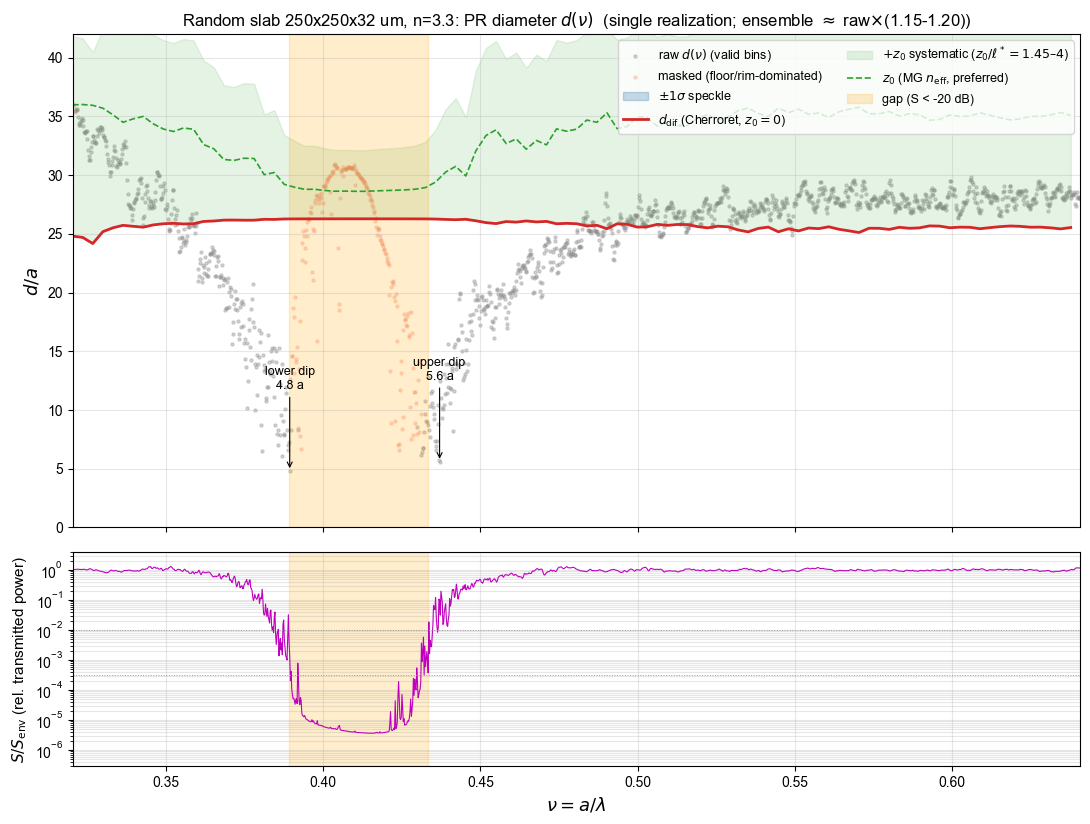

In [8]:
# --- summary: d(nu) +/- speckle band vs diffusive baseline; S(nu) below --------
fig, (ax, axb) = plt.subplots(2, 1, figsize=(13, 9.5), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.07})
ax.scatter(nu[valid], d_nu[valid], s=5, alpha=0.35, color="0.55", label=r"raw $d(\nu)$ (valid bins)")
ax.scatter(nu[~valid], d_nu[~valid], s=5, alpha=0.25, color="salmon",
           label="masked (floor/rim-dominated)")
sm = uniform_filter1d(np.where(valid, d_nu, np.nan), 11, mode="nearest")
ax.fill_between(nu, sm - sig_d, sm + sig_d, color="steelblue", alpha=0.30,
                label=r"$\pm1\sigma$ speckle")
ax.plot(d_dif_nu, d_dif[1], "-", lw=2, color="tab:red", label=r"$d_{\rm dif}$ (Cherroret, $z_0{=}0$)")
ax.fill_between(d_dif_nu, d_dif[1], d_dif_z0[1], color="tab:green",
                alpha=0.12, label=r"$+z_0$ systematic ($z_0/\ell^*{=}1.45$–$4$)")
ax.plot(d_dif_nu, d_dif_z0[0], "--", lw=1.2, color="tab:green", label=r"$z_0$ (MG $n_{\rm eff}$, preferred)")
ax.axvspan(gap_lo, gap_hi, color="orange", alpha=0.20, label=f"gap (S < -20 dB)")
for name, (kk, La_) in dip.items():
    ax.annotate(f"{name} dip\n{d_nu[kk]:.1f} a", (nu[kk], d_nu[kk]), xytext=(nu[kk], d_nu[kk]+7),
                ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_ylim(0, 42); ax.set_ylabel(r"$d/a$", fontsize=13)
ax.set_title(rf"Random slab 250x250x32 um, n=3.3: PR diameter $d(\nu)$  "
             rf"(single realization; ensemble $\approx$ raw$\times$({b_lo:.2f}-{b_hi:.2f}))")
ax.legend(fontsize=9, ncol=2, loc="upper right"); ax.grid(alpha=0.3)
# S_rel = (int I dA) / smooth-envelope fit: transmitted power RELATIVE to the
# gapless interpolation (raw DFT carries the source envelope; not an absolute T).
# Log axis: 1 = envelope level; the gap floor sits ~5 decades down. Guides mark
# the 1e-2 gap-edge threshold and the 10^-3.5 validity-mask floor.
axb.plot(nu, S_rel, lw=0.8, color="m")
axb.set_yscale("log"); axb.set_ylim(3e-7, 4)
axb.axvspan(gap_lo, gap_hi, color="orange", alpha=0.20)
axb.axhline(1e-2, color="0.6", lw=0.7, ls=":"); axb.axhline(10**-3.5, color="0.6", lw=0.7, ls=":")
axb.set_ylabel(r"$S/S_{\rm env}$ (rel. transmitted power)", fontsize=11)
axb.set_xlabel(r"$\nu = a/\lambda$", fontsize=13)
axb.grid(alpha=0.3, which="both"); axb.set_xlim(nu[0], nu[-1])
plt.show()

## Interactive exit-face beam map (linear + log, per-frequency normalized)

In [9]:
# --- slider over frequency bins; slices ONE bin from RAM per redraw ------------
import ipywidgets as W
from IPython.display import display
def show_map(k):
    I = (np.abs(Ex_[:, :, 0, k])**2 + np.abs(Ey_[:, :, 0, k])**2
         + np.abs(Ez_[:, :, 0, k])**2).astype(np.float64)
    In = I/I.max()
    fig = plt.figure(figsize=(12.5, 7.2))
    gs = fig.add_gridspec(2, 2, height_ratios=[14, 2.0], hspace=0.33)
    for j, (ttl, Zm, vmin, vmax) in enumerate((
            (r"linear   $I/I_{\max}$", In, 0, 1),
            (r"log$_{10}(I/I_{\max})$   (floor $10^{-6}$)", np.log10(np.maximum(In, 1e-6)), -6, 0))):
        axm = fig.add_subplot(gs[0, j])
        pm = axm.pcolormesh(xg, yg, Zm.T, vmin=vmin, vmax=vmax, cmap="inferno", shading="auto")
        axm.set_aspect("equal"); axm.set_title(ttl, fontsize=11)
        axm.set_xlabel(r"x [$\mu$m]");  axm.set_ylabel(r"y [$\mu$m]" if j == 0 else "")
        axm.add_patch(plt.Rectangle((-125, -125), 250, 250, fill=False, ec="w", lw=0.8, ls=":"))
        sx = axm.secondary_xaxis("top",   functions=(lambda v: v/a, lambda v: v*a))
        sy = axm.secondary_yaxis("right", functions=(lambda v: v/a, lambda v: v*a))
        sx.set_xlabel(r"x [$a$]", fontsize=9); sy.set_ylabel(r"y [$a$]", fontsize=9)
        fig.colorbar(pm, ax=axm, fraction=0.046, pad=0.10)
    axs = fig.add_subplot(gs[1, :])   # locator strip: S_rel = int I dA / envelope
    axs.plot(nu, S_rel, lw=0.7, color="0.4")              # (relative power, log axis)
    axs.set_yscale("log"); axs.set_ylim(3e-7, 4)
    axs.axvspan(gap_lo, gap_hi, color="orange", alpha=0.3)
    axs.axvline(nu[k], color="r", lw=1.2)
    axs.set_xlabel(r"$\nu$", fontsize=9); axs.set_ylabel(r"$S/S_{\rm env}$", fontsize=9)
    axs.set_xlim(nu[0], nu[-1])
    ingap = "  |  IN GAP (floor-dominated)" if (gap_lo <= nu[k] <= gap_hi) else ""
    fig.suptitle(rf"$\nu$ = {nu[k]:.4f}   $\lambda$ = {a/nu[k]:.3f} $\mu$m   "
                 rf"d = {d_nu[k]:.1f} a{ingap}", y=0.98)
    plt.show()
sl = W.IntSlider(value=int(np.argmin(np.abs(nu-0.50))), min=0, max=N-1, step=1,
                 description="bin", continuous_update=False, layout=W.Layout(width="60%"))
lbl = W.Label()
def _upd(ch=None): lbl.value = f"nu = {nu[sl.value]:.4f}   lambda = {a/nu[sl.value]:.3f} um"
sl.observe(_upd, "value"); _upd()
display(W.HBox([sl, lbl]), W.interactive_output(show_map, {"k": sl}))

Output()